In [62]:
import multiprocessing
import os

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(
    multiprocessing.cpu_count()
)

import batman
import blackjax
import gpjax as gpx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import pandas as pd
from gpjax.kernels import RBF, Linear, Periodic
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from tensorflow_probability.substrates.jax.bijectors import Log
from tensorflow_probability.substrates.jax.distributions import (
    Normal,
    TruncatedNormal,
    TransformedDistribution,
    Uniform,
)

from inference import log_likelihood_function
from kernels import OrnsteinUhlenbeck
from kernelsearch import KernelSearch, describe_kernel, get_trainables, set_trainables
from mcmc import nuts_warmup, run_mcmc
from util import calculate_example_lightcurve, lc_model

jax.config.update("jax_enable_x64", True)

rng_key = jax.random.PRNGKey(42)

Things to consider:
- heteroskedastic noise (supported natively -- check, or maybe not with fitting.. see if that important)
- doing kernel search per time series, or across all time series (loop over all datasets and calculate cumulative likelihood -> cummulative aic/bic)
- (normalise mean?)
- need longer time series data for proper learning

Questions:
- longer time series
- limb darkening fitting

## Load Data

In [130]:
df = pd.read_csv("data/lc.dat", sep=" ", header=None)
x = df[0].to_numpy()
x_min = np.amin(x)
x -= x_min
y = df.iloc[:, 1::2].to_numpy().T
yerr = df.iloc[:, 2::2].to_numpy().T

mask = np.ones_like(x, dtype=bool)
mask[100:324] = False

ld_pars = [
    (0.87, -0.0639),
    (0.70, -0.0109),
    (0.72, -0.0275),
    (0.64, 0.0460),
    (0.58, 0.0736),
    (0.53, 0.1032),
    (0.55, 0.0884),
    (0.51, 0.1080),
    (0.46, 0.1134),
    (0.45, 0.1265),
    (0.41, 0.1348),
    (0.43, 0.1269),
    (0.42, 0.1315),
    (0.41, 0.1334),
    (0.41, 0.1337),
    (0.36, 0.1404),
    (0.32, 0.1565),
    (0.35, 0.1429),
    (0.35, 0.1434),
]

## Get GP models for white light curve

In [64]:
kernel_library = [
    Linear(),
    RBF(),
    OrnsteinUhlenbeck(),
    Periodic(),
]

In [113]:
tree = KernelSearch(
    kernel_library,
    X=jnp.array(x[mask]),
    y=jnp.array(y[-1][mask]),
    obs_stddev=jnp.amax(yerr[-1][mask]),
    verbosity=1,
)

model = tree.search(
    depth=7,
    n_leafs=4,
    patience=1,
)
print(describe_kernel(model))

Fitting Layer 1: 100%|██████████| 4/4 [00:06<00:00,  1.75s/it]


Layer 1 || Current top AICs: [-2955.2424005015996, -2953.9732075033844, -2953.700459402631, 73579851.77628565]


Fitting Layer 2: 100%|██████████| 32/32 [02:25<00:00,  4.53s/it]


Layer 2 || Current top AICs: [-2953.2424144375914, -2953.2424005002827, -2952.998561252375, -2951.973207500648]


Fitting Layer 3: 100%|██████████| 44/44 [04:11<00:00,  5.71s/it]


...

Layer 5 || Current top AICs: [-2957.673800108559, -2957.6737688344256, -2956.357142468492, -2955.6737992646217]


Fitting Layer 6: 100%|██████████| 48/48 [04:48<00:00,  6.02s/it]


Layer 6 || Current top AICs: [-2957.847211284376, -2957.847211280221, -2957.8472104354905, -2957.847170048336]


Fitting Layer 7: 100%|██████████| 48/48 [04:50<00:00,  6.05s/it]


Layer 7 || Current top AICs: [-2955.847211238795, -2955.847211237151, -2955.847211114913, -2955.8472111048823]
Terminated on layer: 7.
Final log likelihood: 1482.923605642188
Final number of model parameter: 4
OU + ((Linear * Linear * Linear) * Linear * RBF)


## Define LC model

In [125]:
def get_lc_model(ld_pars):
    def lc_model(t, params):
        central = orbits.keplerian.Central(
            mass=1.45,
            radius=1.653,
        )

        # The light curve calculation requires an orbit
        orbit = orbits.keplerian.Body(
            central=central,
            period=3.9501907,
            radius=params[0] * central.radius,
            inclination=jnp.deg2rad(89.3),
            time_transit=params[1],
        )

        lc = LimbDarkLightCurve([ld_pars[0], ld_pars[1]]).light_curve(orbit, t=t)
        return lc

    return lc_model

## Define likelihood, prior, posterior

In [126]:
def get_logprob(model, y, lc_model):
    initial_position = {
        "gp_parameter": get_trainables(model, unconstrain=True),
        "lc_parameter": jnp.array([0.10, 0.18]),
    }

    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.1 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=initial_position["lc_parameter"],
            scale=[0.06, 0.05],
        ),
    }

    log_likelihood = log_likelihood_function(
        model.unconstrain(),
        lc_model,
        x,
        y,
        mask,
        fix_gp=False,
        compile=True,
    )

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(params["lc_parameter"])
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## Fits

In [134]:
sols = []
for i in range(len(y) - 1):
    lc_model = jit(get_lc_model(ld_pars[i]))
    log_probability, initial_position = get_logprob(
        model,
        y[i],
        lc_model,
    )

    lbfgsb = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)), method="l-bfgs-b"
    )
    lbfgsb_sol = lbfgsb.run(initial_position)
    sol = lbfgsb_sol.params
    print(sol["lc_parameter"])
    sols.append(sol)

[0.10978814 0.18340492]
[0.110216   0.18430562]
[0.10949002 0.18441496]
[0.10886188 0.18404686]
[0.10860021 0.18413602]
[0.10845837 0.18342114]
[0.10791171 0.18305833]
[0.10740257 0.18310228]
[0.10813179 0.18348539]
[0.10837041 0.18317981]
[0.10796027 0.18344771]
[0.11044458 0.18381139]
[0.10906212 0.18356723]
[0.10819204 0.18364065]
[0.10749114 0.18355069]
[0.1082304  0.18362443]
[0.10840064 0.18355291]
[0.10775256 0.18294744]
[0.10821086 0.18282199]


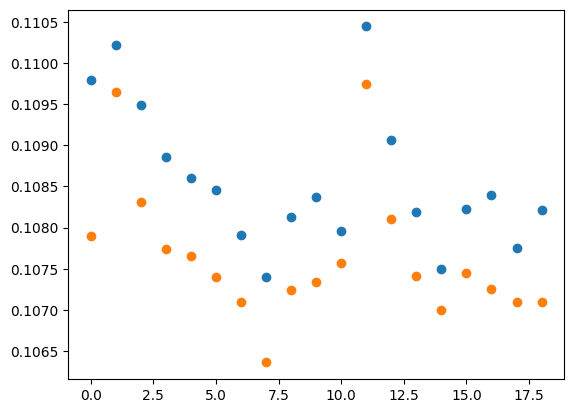

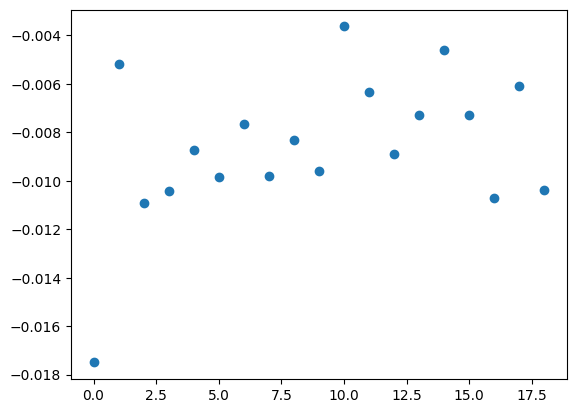

In [138]:
ref = np.array(
    [
        0.10790,
        0.10965,
        0.10831,
        0.10774,
        0.10766,
        0.10740,
        0.10709,
        0.10636,
        0.10724,
        0.10734,
        0.10757,
        0.10975,
        0.10810,
        0.10741,
        0.10700,
        0.10745,
        0.10725,
        0.10710,
        0.10710,
    ]
)

plt.scatter(range(len(y) - 1), [sol["lc_parameter"][0] for sol in sols])
plt.scatter(range(len(y) - 1), ref)

plt.figure()
plt.scatter(range(len(y) - 1), (ref - [sol["lc_parameter"][0] for sol in sols]) / ref)

## Do MCMC

In [139]:
# Adapted from BlackJax's introduction notebook.
num_adapt = 400
num_samples = 400
num_chains = 8

chains = []

for i in range(len(y)):
    lc_model = jit(get_lc_model(ld_pars[i]))
    log_probability, initial_position = get_logprob(model, y[i], lc_model)

    rng_key, warmup_key, sample_key = jax.random.split(rng_key, 3)

    state, parameters = nuts_warmup(
        warmup_key,
        log_probability,
        initial_position,
        num_steps=num_adapt,
    )

    initial_positions = {
        "gp_parameter": jnp.tile(state.position["gp_parameter"], (num_chains, 1)),
        "lc_parameter": jnp.tile(state.position["lc_parameter"], (num_chains, 1)),
    }

    final_state, state_history, info_history = run_mcmc(
        sample_key,
        log_probability,
        parameters,
        initial_positions,
        num_steps=num_samples,
    )

    chain = np.array(
        state_history.position["lc_parameter"].reshape(
            -1, state_history.position["lc_parameter"].shape[-1]
        )
    )
    chains.append(chain)

Running window adaptation
